In [49]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt

KeyError: '9'

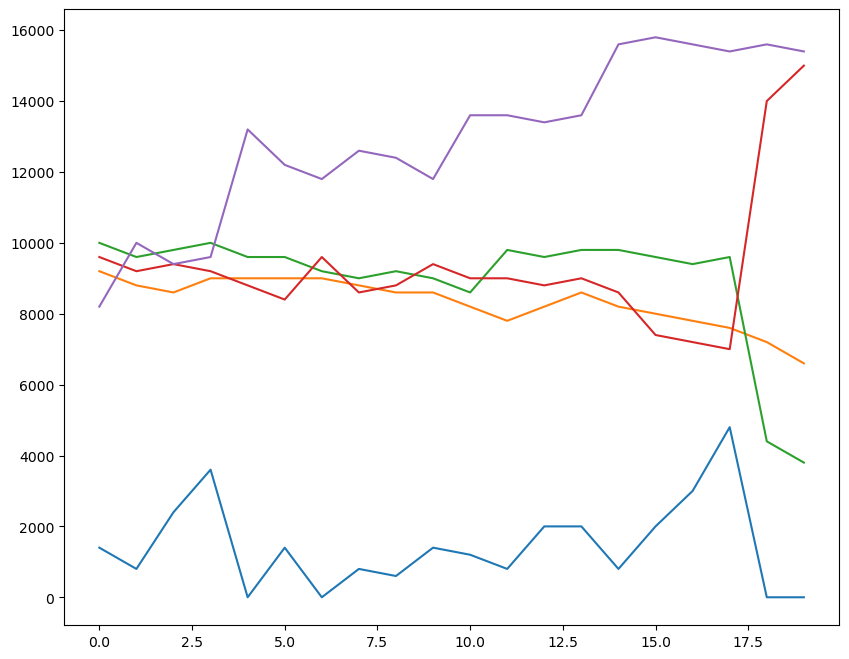

In [108]:
df = pd.read_csv("results.csv")
names={
    "1": "Conservative",
    "2": "Aggressive",
    "3": "Martingale",
    "4": "Probability",
    "5": "AllIn",
    "6": "Manuel",
    "7": "Manuel_2",
    "8": "BadBunny",
}
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(df["pool"], label="pool")
for player in df.keys()[1:]:
    ax.plot(df[player], label=names[player])
#ax.plot(df.values.sum(axis=1), label="Total")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.set_xlabel("Round")  
ax.set_ylabel("Stack")
ax.set_title("Stack evolution")
plt.show()

# Multiples juegos

In [110]:
import os
dir_path = "results"
list_of_files = os.listdir(dir_path)
list_of_files = [f for f in list_of_files if f.endswith(".csv")]
names={
    "pool": "pool",
    "1": "Conservative",
    "2": "Aggressive",
    "3": "Random",
    "4": "Martingale",
    "5": "Probability",
    "6": "AllIn",
    "7": "Manuel",
    "8": "Manuel_wilches",
    "9": "BadBunny",
    "10": "Wilches",
}
df=pd.read_csv(dir_path+'/'+list_of_files[0])
players_list=df.keys()
print("numero de juegos", len(list_of_files))
print("Lista de jugadores", players_list)

numero de juegos 1000
Lista de jugadores Index(['pool', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'], dtype='str')


In [134]:
def plot_all_games(column, n_games, max_rounds=5000, verbose=False, ax=None, zeros=False):
    if n_games is None:
        n_games=len(list_of_files)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.set_xlabel("Round")
        ax.set_ylabel(column)
        ax.set_title(f"{names[column]} evolution")
    else:
        fig = None
    

    acumulative_round = np.zeros(max_rounds)
    counts = np.zeros(max_rounds)
    

    for file in list_of_files[:n_games]:
        df = pd.read_csv(os.path.join(dir_path, file))
        if verbose:
            ax.plot(df[column], alpha=0.3, label=file if n_games<=5 else None)
        values = df[column].to_numpy()[:max_rounds]
        acumulative_round[:len(values)] += values
        counts[:len(values)] += 1
    if zeros:
        mean_round_zeros=acumulative_round/n_games
        ax.plot(mean_round_zeros, label=names[column]+"_zeros", linestyle="--")
    else:
        mean_round = acumulative_round / counts
        ax.plot(mean_round, label=names[column])
    

    if verbose:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        print("total plata inicial",df.iloc[1].sum())

[19636600. 19543000. 19463600. ...   183000.   183000.   182800.]
[1000. 1000. 1000. ...   17.   17.   17.]
total plata inicial 200000


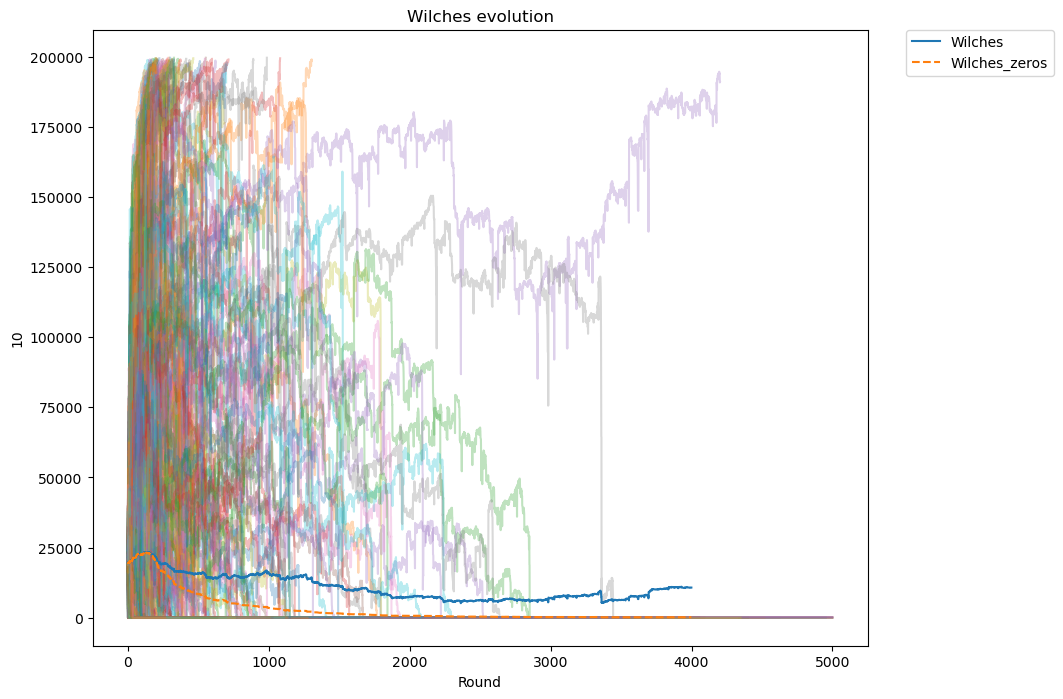

In [125]:
plot_all_games("10", n_games=1000, max_rounds=4000, verbose=True)


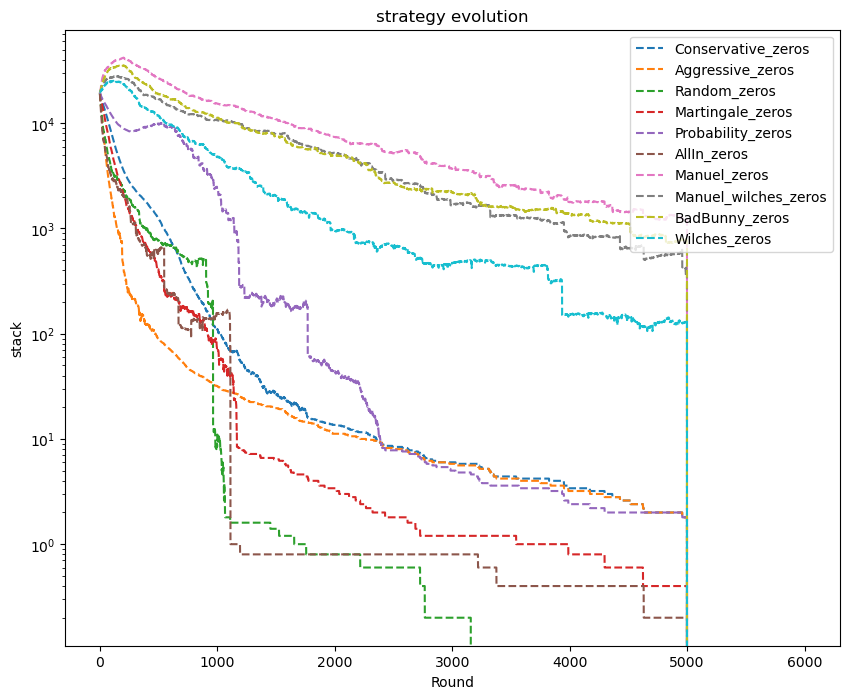

In [136]:
fig , ax = plt.subplots(figsize=(10, 8))
for player in players_list[1:]:
    plot_all_games(player, n_games=None, max_rounds=6000, ax=ax, zeros=True)
ax.legend()
ax.set_xlabel("Round")
ax.set_ylabel("stack")
ax.set_yscale("log")
ax.set_title("strategy evolution")
plt.show()

/tmp/ipykernel_23023/3657654624.py:24: RuntimeWarning: invalid value encountered in divide
  mean_round = acumulative_round / counts


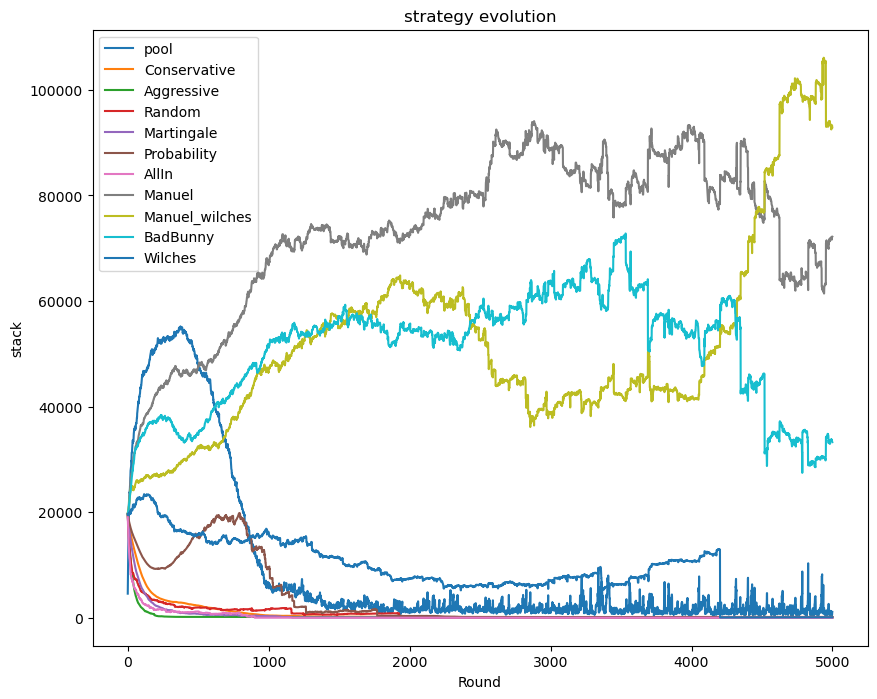

In [132]:
fig , ax = plt.subplots(figsize=(10, 8))
for player in players_list:
    plot_all_games(player, n_games=None, max_rounds=6000, ax=ax, zeros=False)
ax.legend()
ax.set_xlabel("Round")
ax.set_ylabel("stack")
ax.set_title("strategy evolution")
plt.show()

total plata inicial 180000


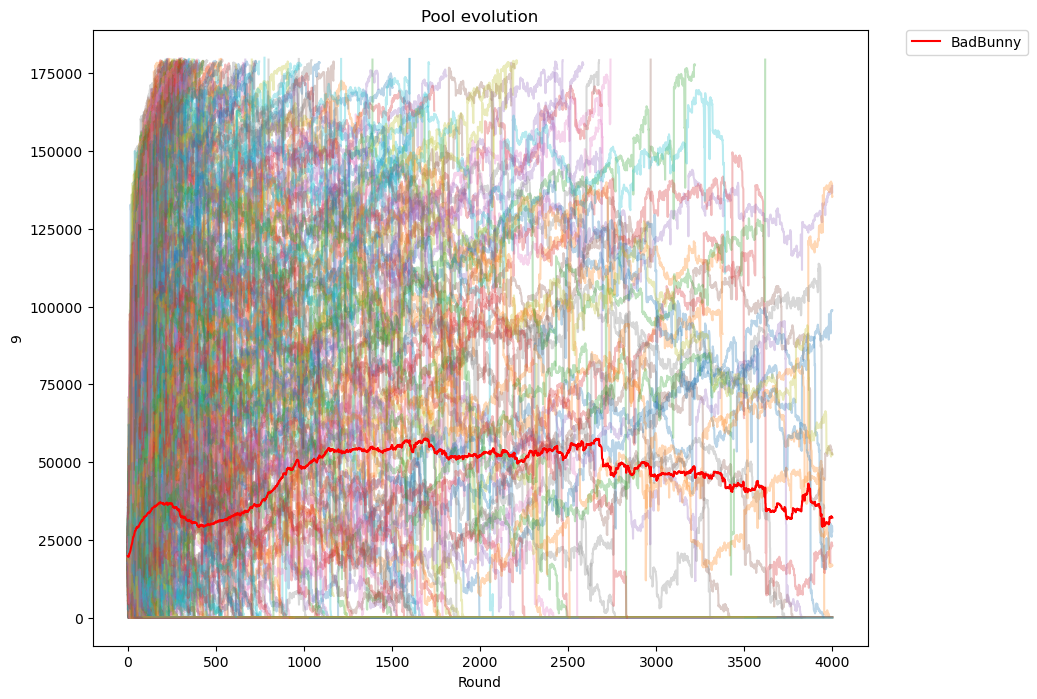

In [25]:
plot_all_games("9", n_games=None, max_rounds=4000)

total plata inicial 180000


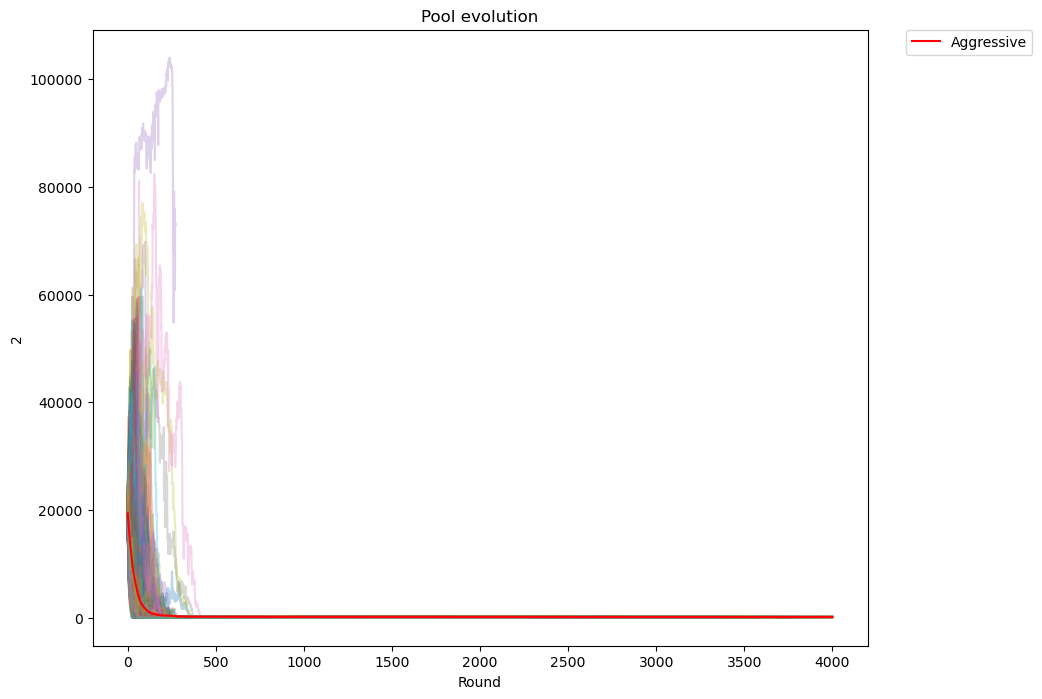

In [30]:
plot_all_games("2", n_games=None, max_rounds=4000)


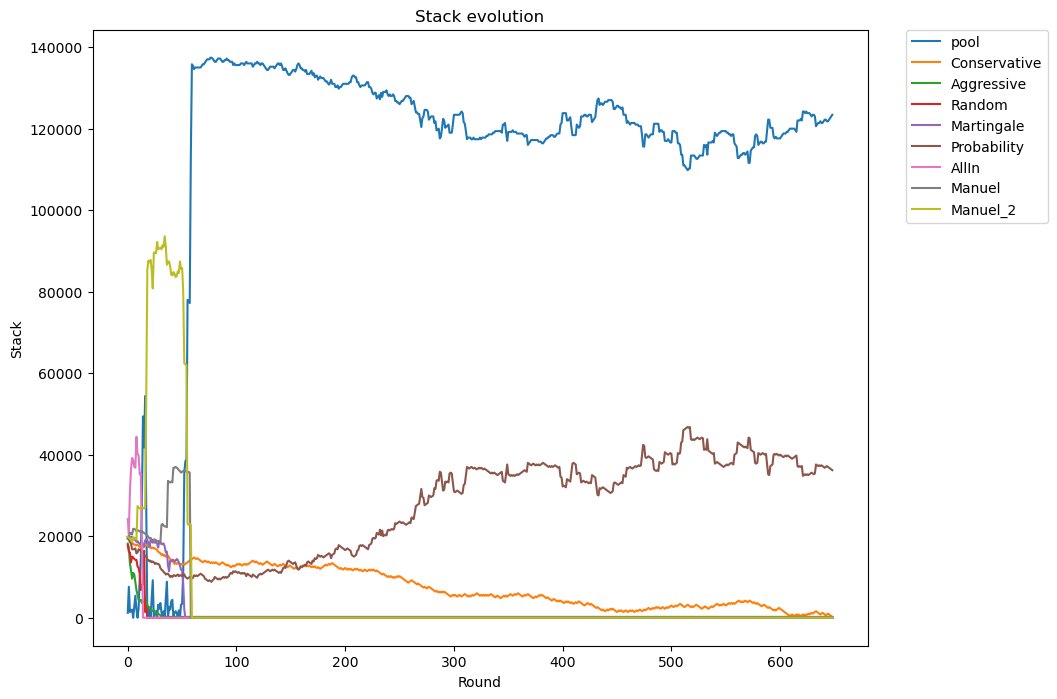

In [67]:
df=pd.read_csv(os.path.join(dir_path, list_of_files[2]))
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(df["pool"], label="pool")
for player in df.keys()[1:]:
    ax.plot(df[player], label=names[player])
#ax.plot(df.values.sum(axis=1), label="Total")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.set_xlabel("Round")  
ax.set_ylabel("Stack")
ax.set_title("Stack evolution")
plt.show()